In [19]:
import seaborn as sns
import torch
import os, json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

MODEL_NAME = "qwen3"
DATA_FOLDER = os.environ.get("ROUTING_DATA_FOLDER", "./layerwise_cka/")
MODE = "xling_kernelsim_change"
LANGS = {
    "tel_Telu": "qwen3_tel__L7-34_nofreeze_200k",
    "kir_Cyrl": "qwen3_kir__L7-34_nofreeze_200k",
    "kan_Knda": "qwen3_kan__L7-34_nofreeze_200k",
    "tha_Thai": "qwen3_tha__L7-34_nofreeze_200k",
}

In [20]:
reloaded_cka_scores = {}
for lang, trained in LANGS.items():
    langcode = lang.split('_')[0]
    if langcode == "eng":
        continue
    filename = f"xling_kernelsim_change_{MODEL_NAME}_flores_{langcode}.json"
    output_file = os.path.join(DATA_FOLDER, filename)
    try:
        with open(output_file, "r") as f:
            reloaded_cka_scores[langcode] = json.load(f)
    except FileNotFoundError:
        print(f"File not found: {output_file}")
        continue

    filename = f"xling_kernelsim_change_{trained}_flores_{langcode}.json"
    output_file = os.path.join(DATA_FOLDER, filename)
    try:
        with open(output_file, "r") as f:
            reloaded_cka_scores[langcode+"_trained"] = json.load(f)
    except FileNotFoundError:
        print(f"File not found: {output_file}")
        continue

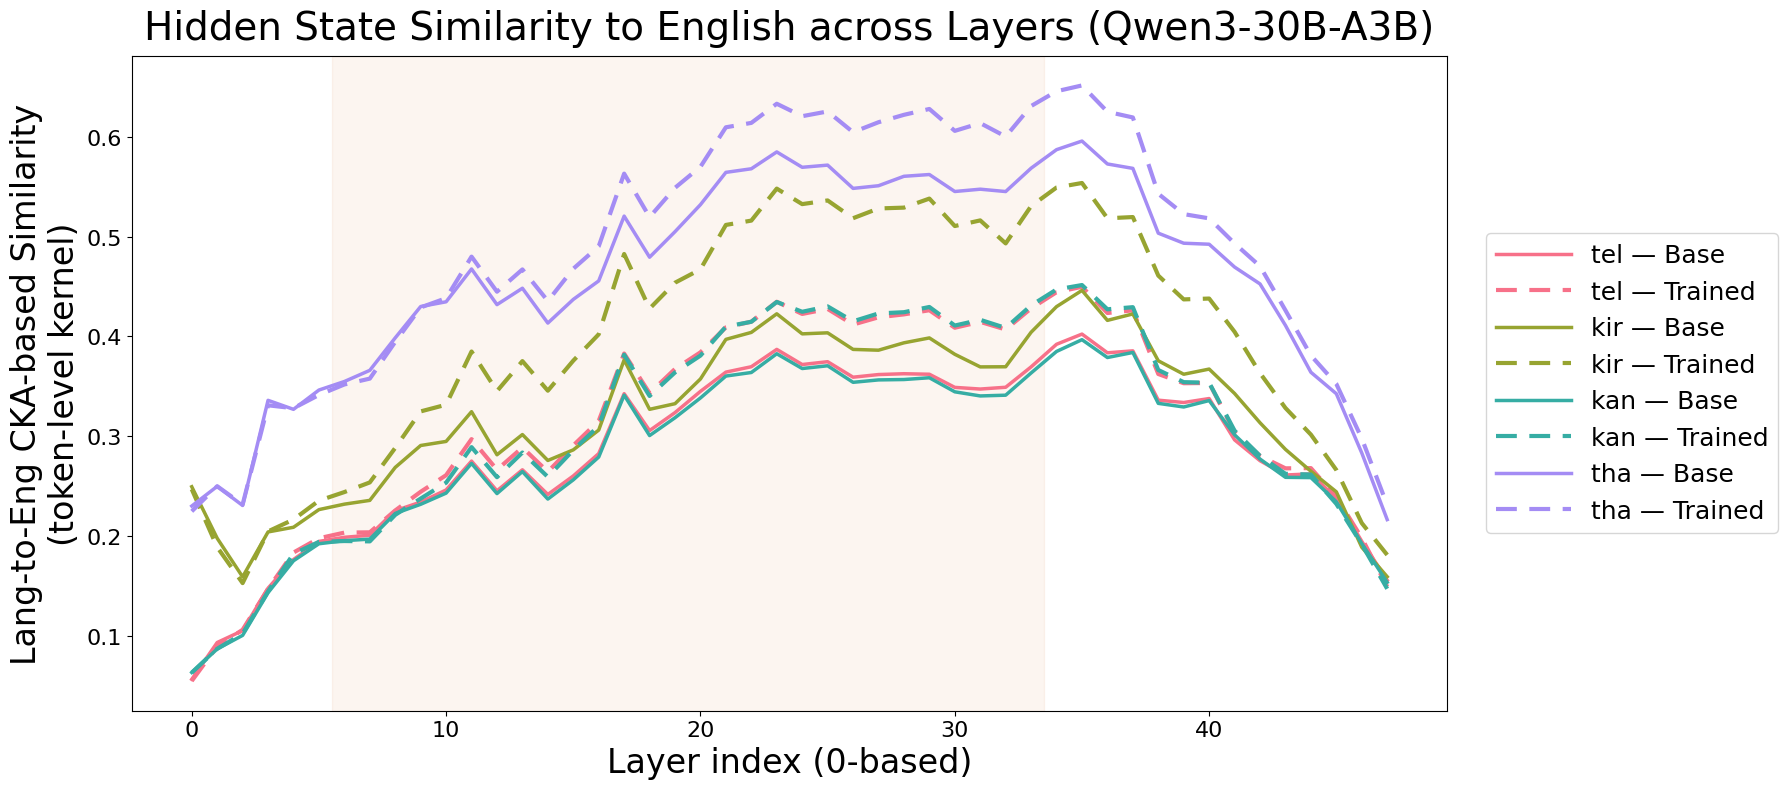

In [26]:
# Use one color per language and line styles to distinguish each model.
languages = list(dict.fromkeys(
    key.removesuffix("_trained")
    for key in reloaded_cka_scores
    if key.removesuffix("_trained") != "eng"
))
colors = dict(zip(languages, sns.color_palette("husl", n_colors=len(languages))))

fig, ax = plt.subplots(figsize=(18, 8))
# Training L7-34 is one-based and inclusive; CKA keys are zero-based.
# Qwen3 has an MoE in every decoder layer, so highlight indices 6 through 33.
min_training_layer, max_training_layer = 7, 34
ax.axvspan(
    min_training_layer - 1 - 0.5, max_training_layer - 1 + 0.5,
    color="#D55E00", alpha=0.06, zorder=0,
)
for lang in languages:
    for suffix, model_label, linestyle, linewidth in [
        ("", "Base", "-", 2.5),
        ("_trained", "Trained", (0, (5, 3)), 3),
    ]:
        key = lang + suffix
        if key not in reloaded_cka_scores:
            continue
        layer_data = reloaded_cka_scores[key]["before"]
        sorted_layers = sorted(int(layer) for layer in layer_data)
        values = np.array([layer_data[str(layer)] for layer in sorted_layers])
        ax.plot(
            sorted_layers, values, label=f"{lang} — {model_label}",
            color=colors[lang], linestyle=linestyle,
            linewidth=linewidth,
            markerfacecolor="white" if model_label == "Base" else colors[lang],
            markeredgewidth=1.2,
        )

ax.set_title(
    f"Hidden State Similarity to English across Layers (Qwen3-30B-A3B)",
    fontsize=28, pad=12,
)
ax.set_xlabel("Layer index (0-based)", fontsize=24)
ax.set_ylabel("Lang-to-Eng CKA-based Similarity\n(token-level kernel)", fontsize=24)
ax.tick_params(axis="both", labelsize=16)
# Matplotlib fills legend columns vertically: put Base first, then Trained.
handles, labels = ax.get_legend_handles_labels()
legend_order = [
    i for model_label in ("Base", "Trained")
    for i, label in enumerate(labels) if label.endswith(f"— {model_label}")
]
ax.legend(
    [handles[i] for i in legend_order], [labels[i] for i in legend_order],
    loc="lower center", bbox_to_anchor=(30, 0.06),
    bbox_transform=ax.get_xaxis_transform(), ncol=2,
    fontsize=18, handlelength=3, columnspacing=1.5,
    framealpha=0.9,
)
fig.tight_layout()
plt.show()
